In [2]:
import open_clip
print("Available Models:", open_clip.list_pretrained())

Available Models: [('RN50', 'openai'), ('RN50', 'yfcc15m'), ('RN50', 'cc12m'), ('RN101', 'openai'), ('RN101', 'yfcc15m'), ('RN50x4', 'openai'), ('RN50x16', 'openai'), ('RN50x64', 'openai'), ('ViT-B-32', 'openai'), ('ViT-B-32', 'laion400m_e31'), ('ViT-B-32', 'laion400m_e32'), ('ViT-B-32', 'laion2b_e16'), ('ViT-B-32', 'laion2b_s34b_b79k'), ('ViT-B-32', 'datacomp_xl_s13b_b90k'), ('ViT-B-32', 'datacomp_m_s128m_b4k'), ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'), ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'), ('ViT-B-32', 'commonpool_m_image_s128m_b4k'), ('ViT-B-32', 'commonpool_m_text_s128m_b4k'), ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'), ('ViT-B-32', 'commonpool_m_s128m_b4k'), ('ViT-B-32', 'datacomp_s_s13m_b4k'), ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'), ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'), ('ViT-B-32', 'commonpool_s_image_s13m_b4k'), ('ViT-B-32', 'commonpool_s_text_s13m_b4k'), ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'), ('ViT-B-32', 'commonpool_s_s13m_b4k'), ('ViT-B-32', 'me

In [3]:
# Load model
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32-quickgelu', pretrained='laion400m_e32')
# ViT-B-32: use a Vision Transformer (ViT) base-size (B) model as the image encoder with an image patch size of 32
# Pretrained on the LAION-400M dataset, epoch = 32 (e32)

print("Preprocess:", preprocess)
# Preprocessing mainly involves resizing to 224px square images and normalizing the image data

Preprocess: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


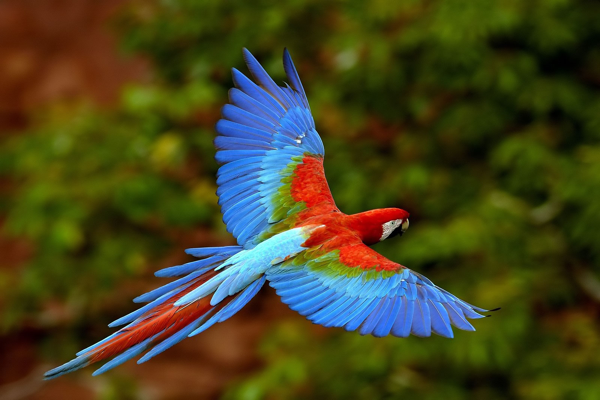

In [4]:
# Load and resize the image
from PIL import Image

input_image = Image.open("images/parrot.jpg").resize((600, 400))
input_image

Image.shape: torch.Size([1, 3, 224, 224]) Image_features.shape: torch.Size([1, 512])


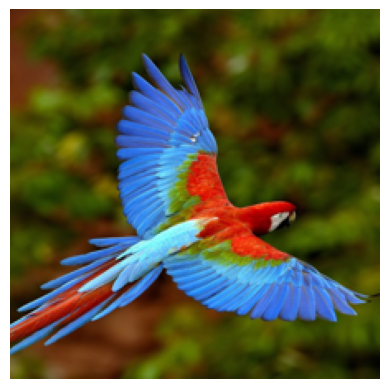

In [5]:
# Preprocess the image, turn it into a CLIP embedding -> image_features
import torch
import matplotlib.pyplot as plt

image = preprocess(input_image).unsqueeze(0)

with torch.no_grad(), torch.amp.autocast("cuda"):   # For saving memory & speeding up training
    image_features = model.encode_image(image)      # Turn into a CLIP embedding
    
print('Image.shape:', image.shape, 'Image_features.shape:', image_features.shape)

# Remove the batch dimension and clone the tensor
img = image.squeeze(0).clone().detach()

# Define standard OpenAI CLIP mean and std deviation
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

# Reverse the normalization: (image * std) + mean
img = img * std + mean

# Clamp values to ensure they stay strictly between [0, 1]
img = torch.clamp(img, 0, 1)

# Permute dimensions from [C, H, W] to [H, W, C] for Matplotlib
img_np = img.permute(1, 2, 0).cpu().numpy()

# Plot the restored image
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [6]:
# Generate text features
text = open_clip.tokenize(["a cat", "a bird", "a dog"])

with torch.no_grad(), torch.amp.autocast("cuda"):   # For saving memory & speeding up training
    text_features = model.encode_text(text)
    
print('Tokenized text shape:', text.shape)
print('Text_features.shape:', text_features.shape)

Tokenized text shape: torch.Size([3, 77])
Text_features.shape: torch.Size([3, 512])


In [7]:
# Computing similarities
"""
    calculate the matching probability scores between a set of image features and text features
"""
def probability_scores(image_features, text_features):
    # feature normalization - scale every vector to a length of 1, ensuring only the angle of the vectors matters for comparison rather than their raw magnitude
    image_features /= image_features.norm(dim=-1, keepdim=True)         # (1, 512)
    text_features /= text_features.norm(dim=-1, keepdim=True)           # (3, 512)
    
    # Cosine similarity matrix - a matrix multiplication between the normalized image features and the transposed normalized text features
    text_probs = (image_features @ text_features.T).softmax(dim=-1)     # (1, 3)

    return text_probs

torch.set_printoptions(precision=3)
# the following 2 operations for Cosine similarity calculation are identical
print("Label probs:", probability_scores(image_features, text_features))
print("Label probs:", torch.nn.functional.cosine_similarity(image_features, text_features).softmax(dim=-1))

Label probs: tensor([[0.314, 0.366, 0.321]])
Label probs: tensor([0.314, 0.366, 0.321])


In [8]:
# Image search
import glob
image_files = glob.glob('images/*.png') + glob.glob('images/*.jpg')
print("Number of images:", len(image_files))

Number of images: 8


In [9]:
# Create image features
def load_image_pil(fn):
    return Image.open(fn)

image_features = []
for fn in image_files:
    im = load_image_pil(fn)
    image_features.append(model.encode_image(preprocess(im).unsqueeze(0)))

image_features = torch.cat(image_features)
print('Image_features.shape:', image_features.shape)

Image_features.shape: torch.Size([8, 512])


Similarities: [0.05251442 0.09571045 0.16520599 0.28141025 0.07308227 0.02744226
 0.20443821 0.04904402]
Argmax: tensor(3)
Best image match:


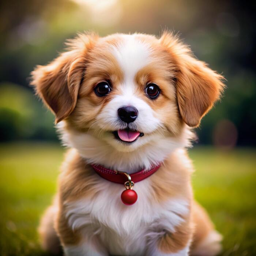

In [10]:
# Embedding a query text and finding the image with the highest similarity
text = open_clip.tokenize(["a puppy"])

with torch.no_grad(), torch.amp.autocast("cuda"):
    text_features = model.encode_text(text)

similarities = torch.nn.functional.cosine_similarity(text_features, image_features)

print('Similarities:', similarities.detach().numpy())
print('Argmax:', similarities.argmax())
print('Best image match:')
load_image_pil(image_files[similarities.argmax()]).resize((256, 256))

In [ ]:
# Using CLIP as a loss function - optimizing the pixels of an image to maximize the similarity of the image with a text prompt
import torchvision
import torchvision.transforms as T

device = 'cuda'
model.to(device)

prompt_input = "A watercolor painting of a swimmer in a cup of coffee"

text = open_clip.tokenize([prompt_input]).to(device)
with torch.no_grad(), torch.amp.autocast("cuda"):
    text_features = model.encode_text(text)
    
im_raw = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
im_raw.requires_grad = True
start_im = im_raw.detach().clone()

optimizer = torch.optim.AdamW([im_raw], lr=0.05) 
losses = []
total_steps = 5000
NUM_CUTS = 32

# calculate the mean Squared Great Circle Distance for pairs of image and text features
def clip_loss(image_features, text_features):
    image_normed = torch.nn.functional.normalize(image_features.unsqueeze(1), dim=2)    # image_features: (num_image, 512) -> image_normed: (num_image, 1, 512)
    text_normed = torch.nn.functional.normalize(text_features.unsqueeze(0), dim=2)      # text_features: (num_text, 512) -> text_normed: (1, num_text, 512)
    sgc_dists = image_normed.sub(text_normed).norm(dim=2).div(2).arcsin().pow(2).mul(4)     
    """
        Squared Great Circle Distance is a geometric loss function that computes the squared arc length 
        between normalized image and text embedding vectors on a unit hypersphere (radius=1).

        On a unit hypersphere, the arc length between 2 normalized vector u (image_feature) and v (text_feature): len(arc) = theta
        So, Squared Great Circle Distance = len(arc)^2 = theta^2.

        The Euclidean distance between two vectors u and v = image_normed.sub(text_normed).norm(dim=2) = 2 * sin(theta/2) -> (num_image, num_text) 
        Then, Squared Great Circle Distance = Euclidean distance.div(2).arcsin().pow(2).mul(4) -> (num_image, num_text). 
    """
    return sgc_dists.mean()     # sgc_dists -> (num_image, num_text), sgc_dists.mean() -> (1,)

# data augmentation: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html
transforms = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),    # random crop each time
    torchvision.transforms.RandomAffine(degrees=3),                     # random affine transform - combine rotation, scaling and translation
    # torchvision.transforms.ColorJitter(),                             # randomly change the brightness, contrast, saturation, etc.
    # torchvision.transforms.GaussianBlur(5),                           # perform Gaussian blur
    torchvision.transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))    # standard pre-training normalization used by CLIP image encoders
])

for step in range(total_steps): 
    im = torch.sigmoid(im_raw)
    # average over a batch of augmentations per step, not a single crop
    views = torch.cat([transforms(im) for _ in range(NUM_CUTS)], dim=0)  # (32, 3, 224, 224)

    image_features = model.encode_image(views)  # (32, 512)
    # add regularization (total variation loss) to penalize high-frequency pixel changes and smoothout the image gradients
    tv_loss = (torch.abs(im[..., :, :-1] - im[..., :, 1:]).mean() + torch.abs(im[..., :-1, :] - im[..., 1:, :]).mean())
    loss = clip_loss(image_features, text_features) + 0.1 * tv_loss
        
    loss.backward()
    losses.append(loss.item())
    optimizer.step()
    optimizer.zero_grad()

    # step logging
    if step % 500 == 0 or step == total_steps - 1:
        print(f">>> Step:{step}, Loss:{loss:.6f}")

In [ ]:
def tensor_to_pil(tensor):
    # Remove batch dimension if present (e.g., shape [1, 3, H, W] -> [3, H, W])
    if tensor.ndim == 4:
        tensor = tensor.squeeze(0)
    # Detach from the computation graph, move to CPU, and convert to PIL Image
    return T.ToPILImage()(tensor.detach().cpu())

tensor_to_pil(im)

In [ ]:
# plot loss
from matplotlib import pyplot as plt
plt.plot(losses)

In [ ]:
# Viewing the difference between the start image and the final result
tensor_to_pil(torch.abs(start_im - im)*2) 